In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
df = pd.read_csv('./data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#### Missing Values

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
for col in df.columns:
    is_na = df[col].isna().sum()
    if is_na > 0:
        print(f'{col} missingness: {np.round((is_na/len(df)), 2)}%')

director missingness: 0.3%
cast missingness: 0.09%
country missingness: 0.09%
date_added missingness: 0.0%
rating missingness: 0.0%
duration missingness: 0.0%


In [5]:
# Fill in missing values
df['country'] = df['country'].fillna(df['country'].mode()[0])
df[['director', 'cast']] = df[['director', 'cast']].fillna('No Data')
df.dropna(inplace=True)

#### Format Date Added

In [6]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

In [7]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()
df['day_added'] = df['date_added'].dt.day
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,25
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September,24
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September,24
3,s4,TV Show,Jailbirds New Orleans,No Data,No Data,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September,24
4,s5,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September,24


#### Color Palette Selection

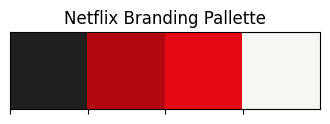

In [8]:
sns.palplot(['#221f1f', '#b20710', '#e50914','#f5f5f1'])
plt.title('Netflix Branding Pallette')
plt.show()

#### Distribution of Movies/TV Shows

In [9]:
type_counts = pd.DataFrame(df.groupby('type').size()*100/len(df)).T.round(2)

In [10]:
type_counts

type,Movie,TV Show
0,69.69,30.31


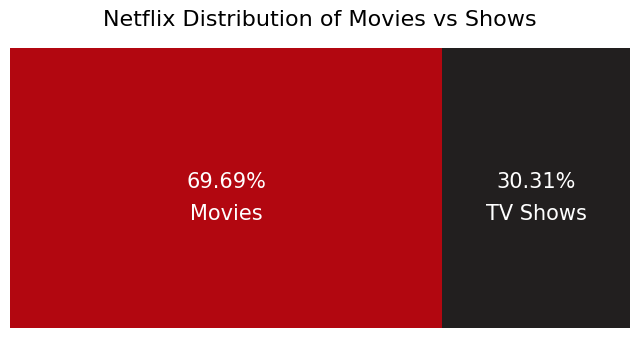

In [11]:
fig, ax = plt.subplots(figsize=(8,4))
movie_perc = type_counts['Movie'].iloc[0]
tv_perc = type_counts['TV Show'].iloc[0]

ax.barh(type_counts.index, type_counts['Movie'], color = '#b20710')
ax.barh(type_counts.index, type_counts['TV Show'], left = type_counts['Movie'], color='#221f1f')

ax.set_xlim(0,100)
ax.set_xticks([])
ax.set_yticks([])

ax.annotate(
    f'{movie_perc}%', 
    xy=((movie_perc/2), 0),
    fontsize=15,
    ha='center',
    color='white'
)
ax.annotate(
    'Movies',
    xy=((movie_perc/2), -.09),
    fontsize=15,
    ha='center',
    color='white'
)
ax.annotate(
    f'{type_counts["TV Show"].iloc[0]}%',
    xy=((movie_perc+tv_perc/2), 0),
    fontsize=15,
    ha='center',
    color='white'
)
ax.annotate(
    'TV Shows',
    xy=((movie_perc+tv_perc/2), -.09),
    fontsize=15,
    ha='center',
    color='white'
)
for s in ['top', 'left', 'right', 'bottom']:
    ax.spines[s].set_visible(False)

plt.title('Netflix Distribution of Movies vs Shows', fontsize=16)
plt.show()

In [12]:
df['country'].nunique()

748

In [13]:
df['country'] = (df['country']
    .replace(', ', ',')
    .replace(' ,', ',')
    .str.split(',')
    .apply(lambda x: x[0]))

In [14]:
df['country'].nunique()

86

In [15]:
long_countries = df.loc[df['country'].apply(lambda x: len(x) > 10)]
long_countries['country'].unique()

<StringArray>
[       'United States',         'South Africa',       'United Kingdom',
          'South Korea',          'New Zealand',          'Switzerland',
         'Saudi Arabia',          'Philippines', 'United Arab Emirates',
          'Netherlands',       'Czech Republic',          'Puerto Rico',
         'Soviet Union',         'West Germany']
Length: 14, dtype: str

In [16]:
df.loc[df['country'].str.contains('North|South')]['country'].unique()

<StringArray>
['South Africa', 'South Korea']
Length: 2, dtype: str

In [17]:
country_mapping = {
    'United Kingdom':'UK',
    'United Arab Emirates':'UAE',
    'Czech Republic': 'Czechia',
    'United States':'USA',
    'South Africa':'S. Africa',
    'South Korea':'S. Korea'
}
df['country'] = df['country'].apply(
    lambda x: country_mapping.get(x,x)
)

In [18]:
df['genre'] = df['listed_in'].replace(', ', ',').replace(' ,', ',').str.split(',')

In [19]:
def generate_heatmap(df, title):
    cmap = LinearSegmentedColormap.from_list('',['#221f1f', '#b20710','#f5f5f1'])
    mlb = MultiLabelBinarizer()
    res = pd.DataFrame(mlb.fit_transform(df['genre']), columns=mlb.classes_, index=df['genre'].index)
    corr = res.corr()
    mask = np.zeros_like(corr, dtype=np.bool)
    mask[np.triu_indices_from(mask)] = True

    fig, ax = plt.subplots(1,1, figsize=(10,7))
    sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-.3, vmax=.3, linewidths=.5, center=0, square=True)
    plt.title(title)
    plt.show()

In [20]:
movie_df = df.query("type == 'Movie'")
tv_df = df.query("type == 'TV Show'")

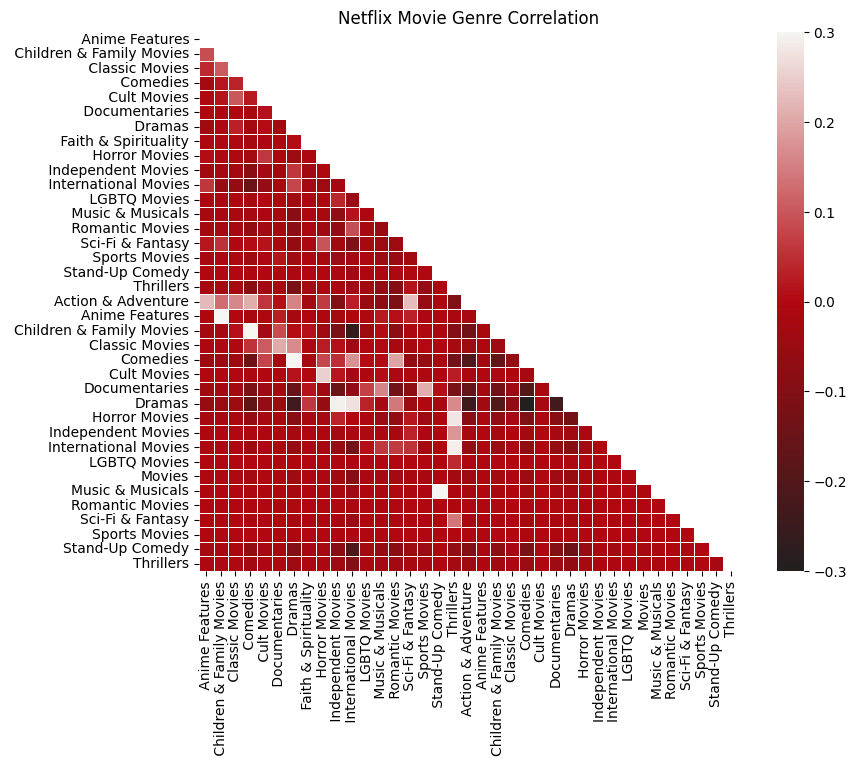

In [21]:
generate_heatmap(movie_df, "Netflix Movie Genre Correlation")

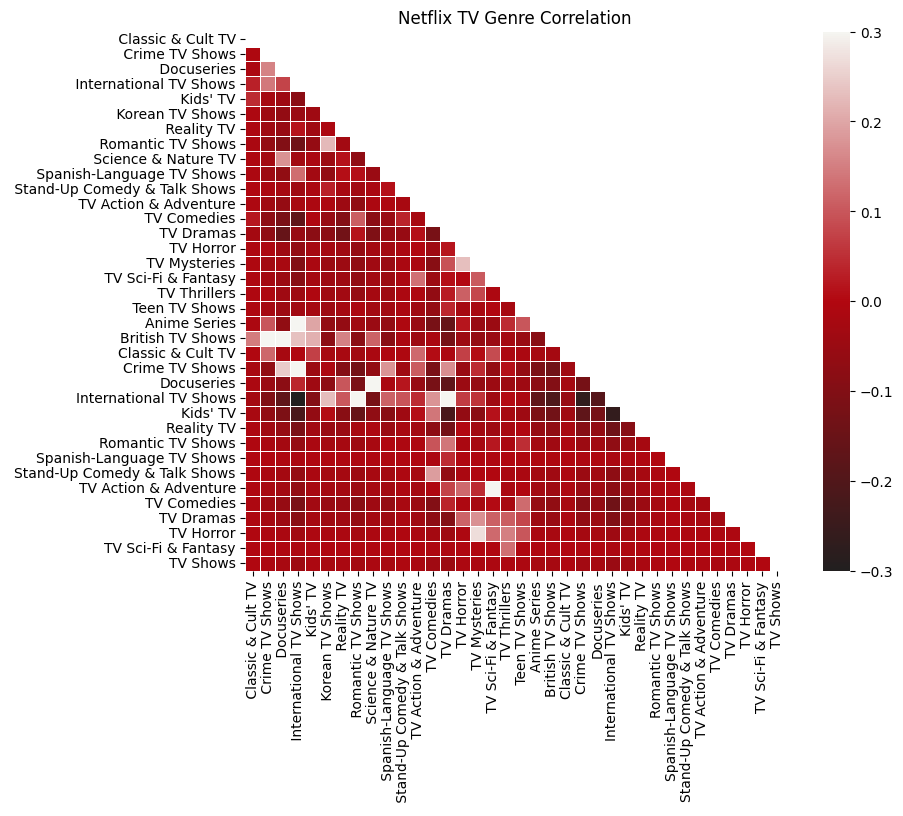

In [22]:
generate_heatmap(tv_df, "Netflix TV Genre Correlation")

In [23]:
top_three_add_years = [2018, 2019, 2020]
top_three_add_years_content = df.loc[df['year_added'].isin(top_three_add_years)]

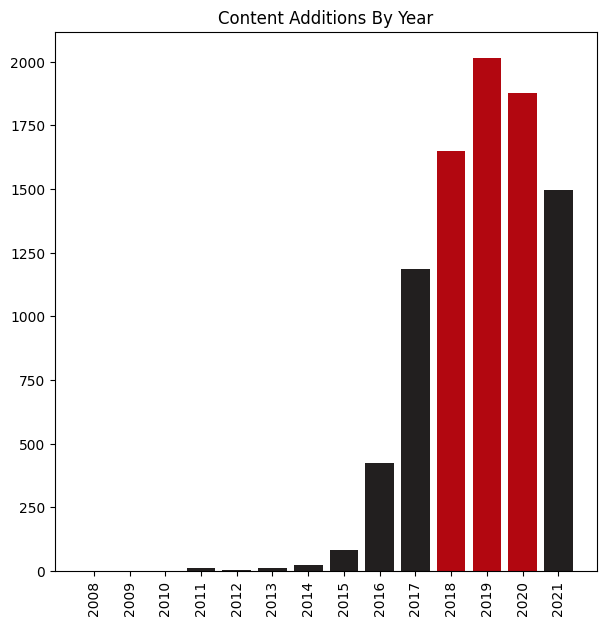

In [24]:
# Check yearly additions
cmap = ['#221f1f' for _ in range(14)]
cmap[10]=cmap[11] = cmap[12] = '#b20710'
yearly_adds = df.groupby('year_added').size()

fig, ax = plt.subplots(figsize=(7,7))
ax.bar(yearly_adds.index,yearly_adds, color=cmap)
ax.set_xticks(yearly_adds.index)

plt.title("Content Additions By Year")
plt.xticks(rotation=90)
plt.show()

In [25]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November','December']
df['month_added'] = pd.Categorical(df['month_added'], categories=months, ordered=True)
monthly_adds = df.groupby('month_added').size()
monthly_add_counts= [monthly_adds.get(month,0) for month in months]

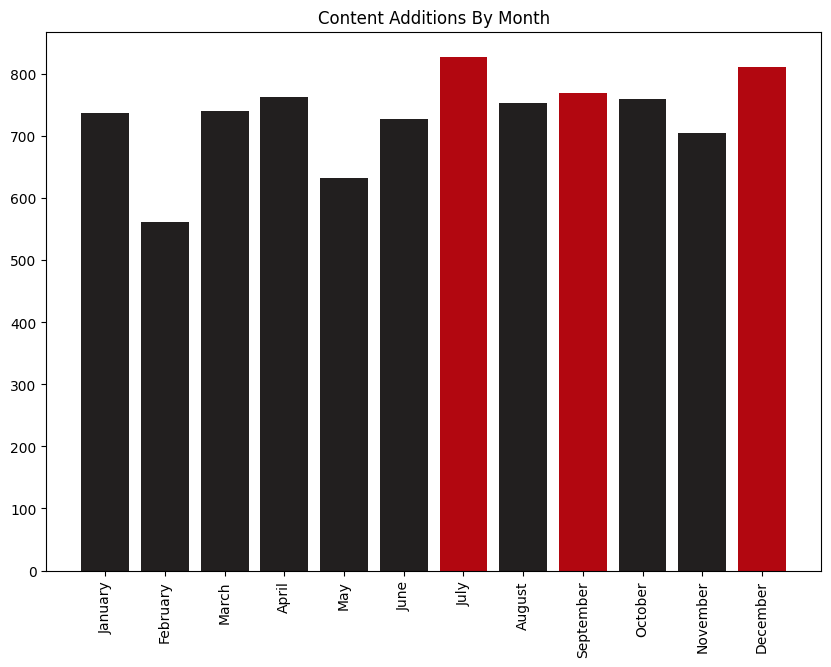

In [26]:
fig, ax = plt.subplots(figsize=(10,7))
cmap = ['#221f1f' for _ in range(12)]
# July, September, December are the top months
cmap[6] = cmap[8] = cmap[11] = '#b20710'
ax.bar(months, monthly_add_counts, color = cmap)

plt.xticks(rotation=90)
plt.title("Content Additions By Month")
plt.show()

In [27]:
data_sub = df.groupby('type')['month_added'].value_counts().unstack().cumsum().T

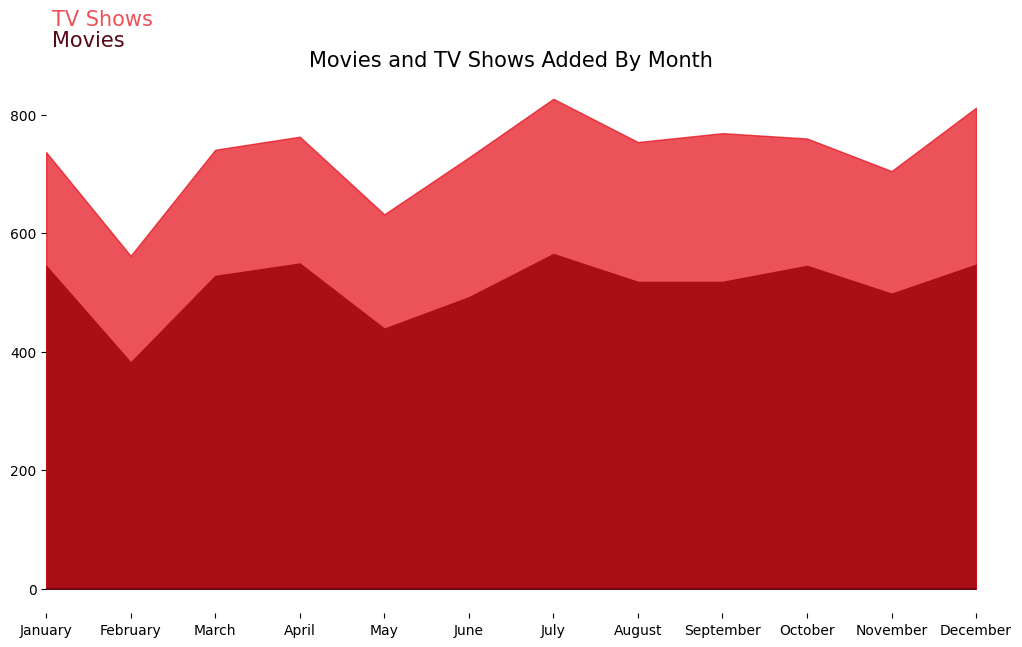

In [31]:
fig, ax = plt.subplots(figsize=(12, 7))
cmap = ['#221f1f','#e50914']
alpha_map = [1, .7]
for i, mtv in enumerate(df.groupby('type').size().index):
    mtv_rel = data_sub[mtv]
    ax.fill_between(mtv_rel.index, 0, mtv_rel,color=cmap[i], alpha=alpha_map[i], label=mtv)

ax.axhline(linewidth=1.5, color='black', alpha=0.4)
ax.grid(False)
ax.margins(x=0)
fig.text(0.13, 0.95, s='TV Shows', fontsize=15, color='#e50914', alpha=.7)
fig.text(0.13, 0.92, s='Movies', fontsize=15, color='#550914')
for s in ['top', 'bottom', 'left', 'right']:
    ax.spines[s].set_visible(False)

plt.title('Movies and TV Shows Added By Month', fontsize=15)
plt.show()

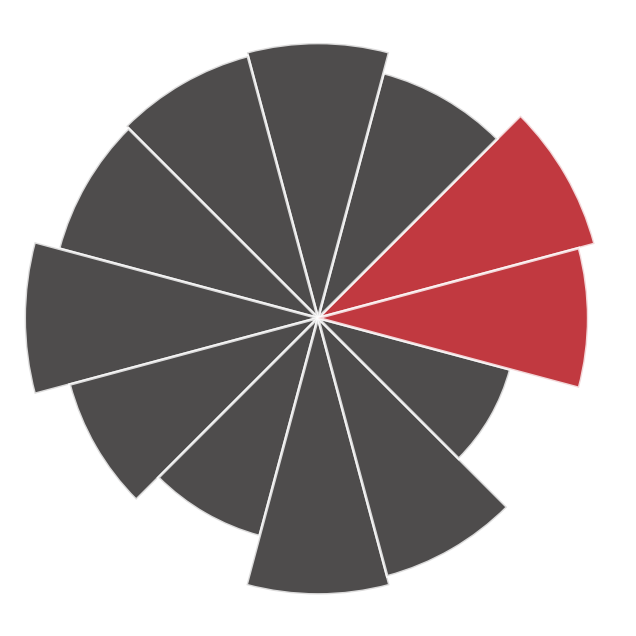

In [98]:
data_sub2 = data_sub
data_sub2['Value'] = data_sub2['Movie']+data_sub2['TV Show']
data_sub2.reset_index()

df_polar = data_sub2.sort_values('month_added', ascending=False)
cmap = ['#221f1f' for _ in range(12)]
cmap[0] = cmap[11] = '#b20710'

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)
plt.axis('off')

value_max = df_polar['Value'].max()
slope = (value_max - 1) / value_max
heights = slope * df_polar.Value + 1
width = 2*np.pi / len(df_polar.index)

indices =list(range(1, len(df_polar.index)+1))
angles = [element * width for element in indices]

bars = ax.bar(
    x=angles,
    height=heights,
    width=width, bottom = 1,
    linewidth=2, 
    edgecolor='w', 
    color=cmap, 
    alpha=.8)

for bar, angle, height, label in zip(bars, angles, heights, df_polar.index):
    rotation = np.rad2deg(angle)
    alignment = ""
    if angle >= np.pi/2 and angle < 3*np.pi/2:
        alignment='right'
        rotation = rotation + 180
    else:
        alignment='left'
        

plt.show()

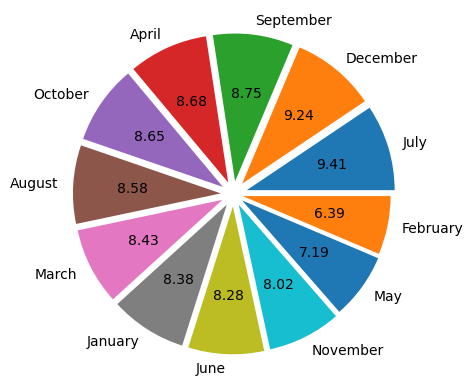

In [85]:
month_perc = np.round((df.month_added.value_counts() * 100) / len(df), 2)
plt.pie(month_perc, labels=month_perc.index, autopct='%.2f', explode=month_perc/100)
plt.show()

In [83]:
month_perc/10

month_added
July         0.941
December     0.924
September    0.875
April        0.868
October      0.865
August       0.858
March        0.843
January      0.838
June         0.828
November     0.802
May          0.719
February     0.639
Name: count, dtype: float64